In [1]:
from pathlib import Path 
import pandas as pd
import geopandas as gpd

from tqdm import tqdm

In [2]:
attributes_shape_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")

lamah_gdf = gpd.read_file(attributes_shape_path)
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]

### Q

In [ ]:
gauge_attr_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")
gauge_attr_df = pd.read_table(gauge_attr_path, header=0, sep=";")
gauge_attr_df.set_index("ID", inplace=True)

lamah_gdf = lamah_gdf.join(gauge_attr_df)

In [4]:
lamah_gdf.q_mean.describe()

count    846.000000
mean       1.951346
std        1.622123
min        0.081000
25%        0.793250
50%        1.473500
75%        2.764750
max       19.689000
Name: q_mean, dtype: float64

<Axes: >

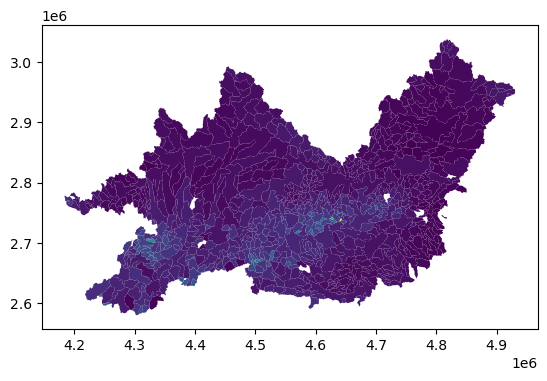

In [5]:
lamah_gdf.plot(column="Q95")

### Basin attributes

In [ ]:
lamah_gdf.area_calc.median()

113.794

### Climate

<Axes: >

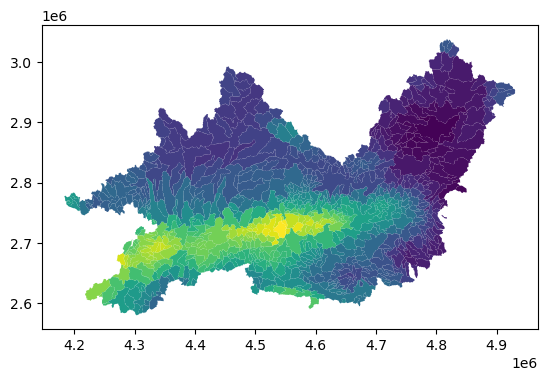

In [7]:
lamah_gdf.plot(column="p_mean")

In [ ]:
lamah_gdf.p_mean.describe()

count    859.000000
mean       3.400489
std        0.999311
min        1.730000
25%        2.615000
50%        3.250000
75%        4.210000
max        5.710000
Name: p_mean, dtype: float64

In [ ]:
sample_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily/ID_1.csv")
sample_df = pd.read_table(sample_path, header=0, sep=";")


In [ ]:
from collections import defaultdict

In [16]:
df = pd.read_table(ts_path / "daily/ID_1.csv", header=0, sep=";")

In [18]:
df["swe"] / 1000

0        0.24069
1        0.25413
2        0.26514
3        0.29551
4        0.32231
          ...   
14239    0.23990
14240    0.24529
14241    0.24540
14242    0.24541
14243    0.24544
Name: swe, Length: 14244, dtype: float64

In [11]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries")

file_list = list(ts_path.rglob("*.csv"))

t_basin_dict = defaultdict(list)
swe_list_dict = {}
swe_min_dict = {}

for file in tqdm(file_list):

	basin_id = file.stem.split("_")[1]

	with open(file, "r") as f: 
		df = pd.read_table(f, header=0, sep=";")

		t_basin_dict[basin_id].append(df["2m_temp_mean"].mean())
		t_basin_dict[basin_id].append(df["2m_temp_mean"].min())
		t_basin_dict[basin_id].append(df["2m_temp_mean"].max())

		swe_list_dict[basin_id] = df["swe"].mean()
		swe_min_dict[basin_id] = df["swe"].max()

  0%|          | 0/859 [00:00<?, ?it/s]

100%|██████████| 859/859 [00:51<00:00, 16.74it/s]


In [12]:
t_basin_dict = dict(sorted(t_basin_dict.items(), key=lambda item: int(item[0])))
t_basin_df = pd.DataFrame(data=t_basin_dict.values(), columns=["mean", "min", "max"], index=t_basin_dict.keys())
lamah_gdf["temp"] = t_basin_df["mean"].values

In [13]:
import numpy as np 

alpine_swe_means = []
alpine_swe_mins = []

for basin_id in swe_list_dict.keys(): 
    
	if strata_ids.loc[int(basin_id), "names"] == "alpine": 

		alpine_swe_means.append(swe_list_dict[basin_id])
		alpine_swe_mins.append(swe_min_dict[basin_id])

print(np.mean(alpine_swe_means), np.max(alpine_swe_mins))


571.7211256299975 7460.14


In [14]:
alpine_swe_means

[571.1548146588037,
 4857.613426705981,
 1765.0984758494806,
 1711.5665922493681,
 641.2187580735748,
 176.6812342038753,
 187.50426284751472,
 181.75776607694468,
 218.07491505195173,
 179.40744875035105,
 160.36170176916596,
 158.60401221566974,
 154.45843583263127,
 132.28673265936536,
 150.05344355518113,
 128.2882694467846,
 118.26949311991014,
 217.76273237854537,
 122.81402766076945,
 211.63435341196293,
 185.18460685200787,
 353.5050673967987,
 4184.69595549003,
 140.58306234203877,
 114.50196222971074,
 104.97400238696994,
 103.65275765234485,
 247.2922900870542,
 233.10999578770006,
 232.2589455209211,
 126.86341055883179,
 1081.2979352709913,
 3579.0694215108115,
 454.2594685481606,
 381.8170226060095,
 3283.240659224937,
 207.97001684919965,
 591.1713395113733,
 157.78709210895815,
 211.16872507722553,
 206.07110151642797,
 146.38430286436392,
 134.91357413647853,
 731.4843892165122,
 210.61223111485538,
 160.9087896658242,
 140.3162264813255,
 95.62518604324627,
 109.77974

<Axes: >

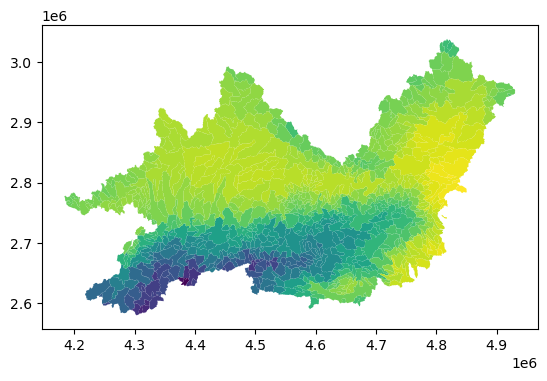

In [15]:
lamah_gdf.plot("temp")